<a href="https://colab.research.google.com/github/waghvaishnav/Deep-Learning-PlayGround-Hub/blob/main/Model_Optimization_in_deep_learning_Batch_Normalization_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [30]:
# importing required modeules
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader,Subset
from torchvision import datasets,transforms
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

In [31]:
# transforms the data
transform = transforms.Compose([transforms.ToTensor(),transforms.Normalize((0.5,),(0.5,))])

# datasets
train_data = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=transform
)

test_data = datasets.MNIST(root="data",
                           train=False,
                           download=True,
                           transform=transform)

# creating subset
train_subset = Subset(train_data,torch.arange(5000))
test_subset = Subset(test_data,torch.arange(1000))

#create batches
train_loader = DataLoader(train_subset,batch_size=60,shuffle=True)
test_loader  = DataLoader(test_subset,batch_size=60,shuffle=True)

# Accuracies without Batch Normalization

In [32]:
class Classifier_model(nn.Module):
  def __init__(self):
    super().__init__()
    self.network = nn.Sequential(
        nn.Flatten(),
        nn.Linear(28*28,128),

        nn.ReLU(),
        nn.Linear(128,64),
        nn.ReLU(),
        nn.Linear(64,10)
    )

  def forward(self,x):
    return self.network(x)

In [33]:
def train_model(model,train_loader,test_loader,optimizer,criterion,epochs=5):

  val_accuracies = []
  for epochs in range(epochs):

    # model training:
    model.train()

    for batch,(images,labels) in enumerate(train_loader):
      optimizer.zero_grad()
      outputs = model(images)
      loss = criterion(outputs,labels)

      # backpropagation
      loss.backward()

      # weight updation:
      optimizer.step()

      if batch % 100 == 0:
        print(f"epoch {epochs}, batch {batch} , train loss : {loss.item():0.2f}")

    # model evaluation:
    model.eval()
    y_pred,y_true = [],[]
    with torch.no_grad():
      for img,labels in test_loader:
        outputs1 = model(img)
        loss = criterion(outputs1,labels)

        _,predicted = torch.max(outputs1,1)
        y_true.extend(labels.numpy())
        y_pred.extend(predicted.numpy())
    val_accuracy = accuracy_score(y_true,y_pred)
    val_accuracies.append(val_accuracy)

  return val_accuracies

In [34]:
model = Classifier_model()
criterion = nn.CrossEntropyLoss()
optimizer= optim.Adam(model.parameters(),lr=0.001)

# provides the values to the model to by function
accuracies_with_no_bn = train_model(model,train_loader,test_loader,optimizer,criterion,10)

epoch 0, batch 0 , train loss : 2.29
epoch 1, batch 0 , train loss : 0.54
epoch 2, batch 0 , train loss : 0.37
epoch 3, batch 0 , train loss : 0.28
epoch 4, batch 0 , train loss : 0.32
epoch 5, batch 0 , train loss : 0.54
epoch 6, batch 0 , train loss : 0.21
epoch 7, batch 0 , train loss : 0.27
epoch 8, batch 0 , train loss : 0.07
epoch 9, batch 0 , train loss : 0.16


In [35]:
print(accuracies_with_no_bn)

[0.807, 0.858, 0.874, 0.871, 0.88, 0.889, 0.89, 0.885, 0.88, 0.9]


# Accuracies with Batch Normalization

In [36]:
class Classifier_model(nn.Module):
  def __init__(self):
    super().__init__()
    self.network = nn.Sequential(
        nn.Flatten(),
        nn.Linear(28*28,128),
        nn.BatchNorm1d(128),
        nn.ReLU(),
        nn.Linear(128,64),
        nn.BatchNorm1d(64),
        nn.ReLU(),
        nn.Linear(64,10)
    )

  def forward(self,x):
    return self.network(x)

In [39]:
model_bn = Classifier_model()
criterion = nn.CrossEntropyLoss()
optimizer= optim.Adam(model_bn.parameters(),lr=0.001)

# provides the values to the model to by function
accuracies_with_bn = train_model(model_bn,train_loader,test_loader,optimizer,criterion,10)

epoch 0, batch 0 , train loss : 2.29
epoch 1, batch 0 , train loss : 0.44
epoch 2, batch 0 , train loss : 0.19
epoch 3, batch 0 , train loss : 0.06
epoch 4, batch 0 , train loss : 0.07
epoch 5, batch 0 , train loss : 0.03
epoch 6, batch 0 , train loss : 0.03
epoch 7, batch 0 , train loss : 0.03
epoch 8, batch 0 , train loss : 0.02
epoch 9, batch 0 , train loss : 0.01


In [40]:
print(accuracies_with_bn)

[0.876, 0.913, 0.922, 0.93, 0.928, 0.945, 0.945, 0.947, 0.946, 0.939]


visualization plot for accuracies without batch normalization / Accuracies with Batch Normalization

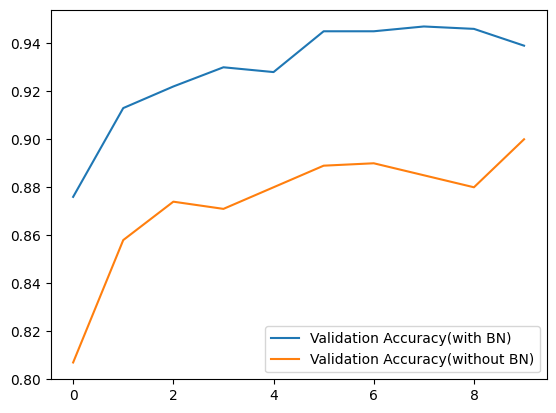

In [42]:
plt.plot(accuracies_with_bn,label="Validation Accuracy(with BN)")
plt.plot(accuracies_with_no_bn,label="Validation Accuracy(without BN)")
plt.legend()
plt.show()